### Exploring Ultra-Flexible Tentacle Electrode Data - MOUSE Dorsal CA1 + Dentate Gyrus

This notebook serves to explore different preprocessing and postprocessing steps with spikeInterface using UFTE LFP data. 

***
### Loading data

In [13]:
import spikeinterface as si 
import spikeinterface.preprocessing as spre
from dataLoading_utils import getXMLData
from dataAnalysis_utils import find_repetitive_channels
import numpy as np
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
from probeinterface import Probe, ProbeGroup, generate_linear_probe, generate_multi_shank, combine_probes 
from probeinterface.plotting import plot_probe

In [14]:
#dat_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\External_Data\Viktor_Budapest\3170_day8_260415_170145\amplifier.dat" 
#xml_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\External_Data\Viktor_Budapest\3170_day8_260415_170145\amplifier.xml" 
dat_path = r"/Volumes/Trenholm2/neuroTechData/Viktor_Budapest/3171_day12_260420_124757/3171_day12_260420_124757/amplifier.dat" 
xml_path = r"/Volumes/Trenholm2/neuroTechData/Viktor_Budapest/3171_day12_260420_124757/3171_day12_260420_124757/amplifier.xml" 

channel_ids, skippedChannels, xml_data = getXMLData(xml_path)
nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data

samplingRate = 20000 # for viktor mouse XML is wrong

print(f"Number of bits: {nBits}, Number of channels: {nChannels}, Sampling rate: {samplingRate} Hz, Offset: {offset}, LFP sampling rate: {lfpSamplingRate} Hz")

uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf

# TODO: Voltage range ? = 10

Number of bits: 16, Number of channels: 64, Sampling rate: 20000 Hz, Offset: 0.0, LFP sampling rate: 2000.0 Hz


### Create a Recording object

Select only channels from shank 2 ([31:])

In [15]:
full_recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=np.arange(nChannels), is_filtered=False, gain_to_uV=uV_per_count, offset_to_uV=0.0)

shank2_channel_ids = np.array(channel_ids[32:])
shank2_recording = full_recording.select_channels(channel_ids=shank2_channel_ids)

shank2_recording

ChannelSliceRecording: 32 channels - 20.0kHz - 1 segments - 68,651,904 samples 
                       3,432.60s (57.21 minutes) - int16 dtype - 4.09 GiB

In [16]:
%matplotlib widget

traces = shank2_recording.get_traces(channel_ids=shank2_channel_ids[-10:], start_frame=0, end_frame=10000, return_in_uV=True)  
sw.plot_traces(shank2_recording, channel_ids=shank2_channel_ids[-10:], return_in_uV=True, backend="ipywidgets")


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

### Create a Probe

First create a flat probe given the known geometry and model the wire bending to get the final x and y coordinates for each contact site. 

We will first work with shank 3. The flat probe has 50um between each contact site in depth 

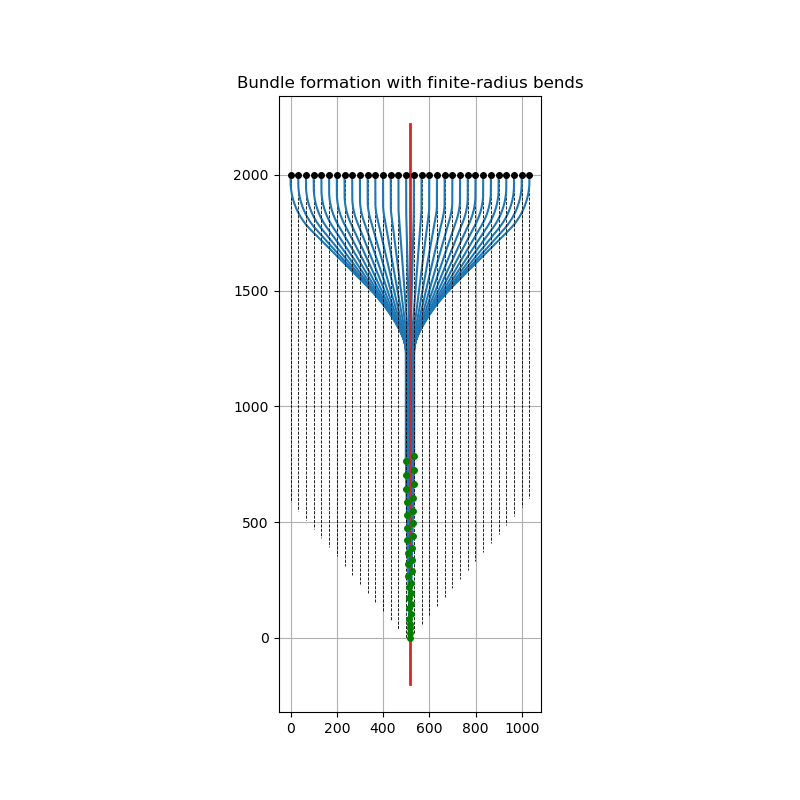

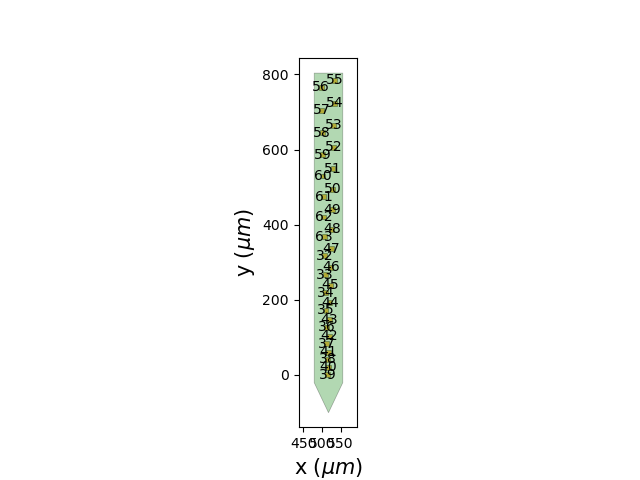

In [17]:
from clean_bending_model import BundleParameters, run_from_array, create_flat_geom

# set parameters for probe geometry 
num_contact_sites = 32
y_flat_contact_dist = 19.5 # um 
x_flat_contact_dist = 33.3 # um (based on figure from https://www.nature.com/articles/s41467-024-49226-9#Sec7)
base_length = 2000.0  # choose something comfortably larger than the max y offset

# create the flat geometry for the electrode tips and the base of the probe
electrode_tips = create_flat_geom(num_contact_sites, x_flat_contact_dist, y_flat_contact_dist)
electrode_base = np.column_stack((electrode_tips[:,0], np.ones(num_contact_sites)*base_length))

# model the bundling of the probe and get the new coordinates for the electrode tips and ends of the probe
#TODO: find better params ? 
params = BundleParameters(
    first_bend_distance=150.0,
    max_bend_angle_deg=45.0,
    bundle_ratio=0.035,
    first_radius=300.0,
    second_radius=300.0,
)

result = run_from_array(electrode_base, electrode_tips,params=params, make_plot=True) # positions are in result.ends and result.tips

# create the SpikeInterface probe object and plot it
probe = Probe(ndim=2, si_units='um')
probe.set_contacts(positions=result.ends, shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe.set_device_channel_indices(np.arange(num_contact_sites))
probe.set_contact_ids(shank2_channel_ids)
probe.create_auto_shape()

# plot the probe geometry to check it looks correct
# plot_probe(probe, with_contact_id=True, with_device_index=True)
    
# link the probe geometry to our recording object 
shank2_recording.set_probe(probe, in_place=True)

sw.plot_probe_map(shank2_recording, with_channel_ids=True, backend="matplotlib")

In [18]:
#print(np.sort(result.ends[:,0]-498.08475))
np.set_printoptions(suppress=True)
#print(np.sort(result.ends[:,1]-.20273302))


print(np.sort(siteLoc[32:,0] - 3000) - np.sort(result.ends[:,0]-498.08475))
print(np.sort(siteLoc[32:,1]) - np.sort(result.ends[:,1]-.20273302))

print("--------------------------------------------------")
siteLoc = np.array([(37.75, 732), ( 0, 698), ( 36.53225807, 678), ( 1.21774194, 645), ( 35.31451613, 625), ( 2.43548387, 593), ( 34.0967742, 573), ( 3.65322581, 542), ( 32.87903226, 522), ( 4.87096774, 491), ( 31.66129033, 472), ( 6.08870968, 442), ( 30.44354839, 422), ( 7.30645162, 393), ( 29.22580645, 374), ( 8.524193551, 346), ( 28.008064519, 326), ( 9.741935487, 299), ( 26.790322584, 280), ( 10.959677422, 253), ( 25.572580648, 234), ( 12.177419358, 209), ( 24.354838713, 189), ( 13.395161293, 165), ( 23.137096777, 145), ( 14.612903229, 122), ( 21.919354842, 102), ( 15.830645164, 80.22594789), ( 20.701612906, 60.72594789), ( 17.0483871, 39.56206844), ( 19.483870971, 20.06206844), ( 18.266129035, 0), ( 3037.75, 732), ( 3000, 698), ( 3036.53225807, 678), ( 3001.21774194, 645), ( 3035.31451613, 625), ( 3002.43548387, 593), ( 3034.0967742, 573), ( 3003.65322581, 542), ( 3032.87903226, 522), ( 3004.87096774, 491), ( 3031.66129033, 472), ( 3006.08870968, 442), ( 3030.44354839, 422), ( 3007.30645162, 393), ( 3029.22580645, 374), ( 3008.524193551, 346), ( 3028.008064519, 326), ( 3009.741935487, 299), ( 3026.790322584, 280), ( 3010.959677422, 253), ( 3025.572580648, 234), ( 3012.177419358, 209), ( 3024.354838713, 189), ( 3013.395161293, 165), ( 3023.137096777, 145), ( 3014.612903229, 122), ( 3021.919354842, 102), ( 3015.830645164, 80.22594789), ( 3020.701612906, 60.72594789), ( 3017.0483871, 39.56206844), ( 3019.483870971, 20.06206844), ( 3018.266129035, 0)])
siteMap = [8, 9, 7, 10, 6, 11, 5, 12, 4, 13, 3, 14, 2, 15, 1, 16, 32, 17, 31, 18, 30, 19, 29, 20, 28, 21, 27, 22, 26, 23, 25, 24, 56, 57, 55, 58, 54, 59, 53, 60, 52, 61, 51, 62, 50, 63, 49, 64, 48, 33, 47, 34, 46, 35, 45, 36, 44, 37, 43, 38, 42, 39, 41, 40]

#print(np.sort(siteLoc[32:,0] - 3000))
#print(np.sort(siteLoc[32:,1]))

[0.         0.05224194 0.10448387 0.15672581 0.20896774 0.26120968
 0.31345162 0.36569355 0.41793549 0.47017742 0.52241936 0.57466129
 0.62690323 0.67914516 0.7313871  0.78362904 0.83587097 0.88811291
 0.94035484 0.99259678 1.04483871 1.09708065 1.14932258 1.20156452
 1.25380645 1.30604839 1.35829033 1.41053226 1.4627742  1.51501613
 1.56725807 1.6195    ]
[  0.           0.56206844  -1.04593169   0.61794776  -2.56471367
  -0.29066156  -4.51693916  -1.01693916  -6.75956777  -2.25956777
  -9.49495037  -3.99495037 -13.70307347  -6.20307347 -17.36744933
  -9.86744933 -21.47508472 -12.97508472 -27.01647658 -17.51647658
 -31.98563514 -21.48563514 -38.38013563 -26.88013563 -44.20120024
 -32.70120024 -51.45381217 -38.95381217 -59.14686477 -45.64686477
 -67.29334883 -52.79334883]
--------------------------------------------------


# Preprocessing: 
### Remove Noisy Channels

First those labeled in the XML file and next those detected by SpikeInterface 

Shank 2 channels to skip: []


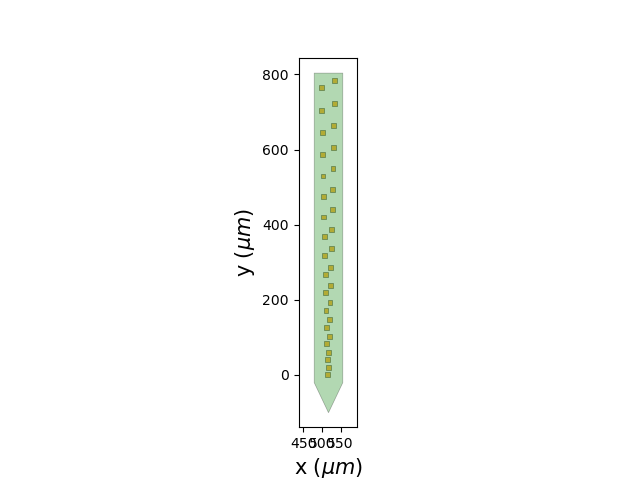

In [19]:
# STEP 1: remove channels already identified as bad in the xml file
shank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)
print(f"Shank 2 channels to skip: {shank2_skipped_channels}")  


clean_recording = shank2_recording.remove_channels(shank2_skipped_channels)
clean_channel_ids = clean_recording.get_channel_ids()
sw.plot_probe_map(clean_recording, backend="matplotlib")

IBL-defined Bad channel IDs: []


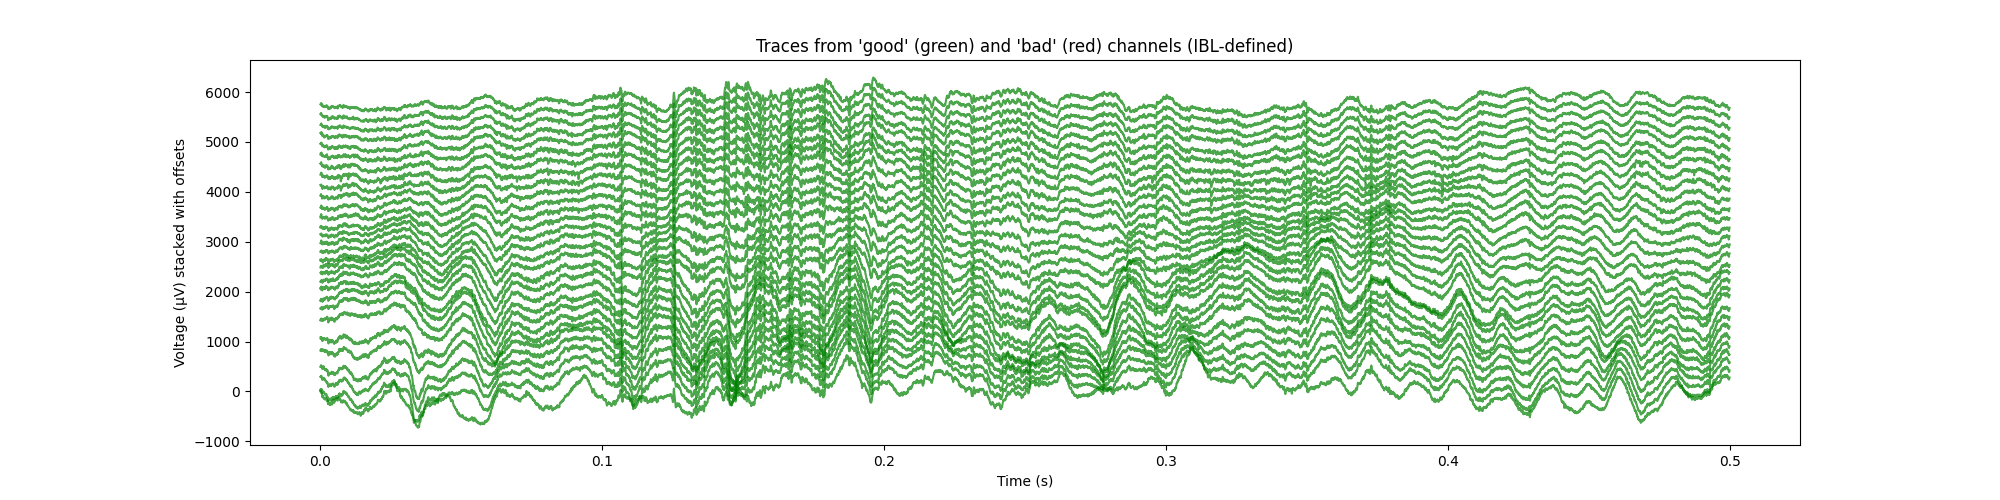

In [50]:
# STEP 2: detect bad channels as defined by IBL 

bad_channel_ids, channel_labels = spre.detect_bad_channels(clean_recording, 
                         method='coherence+psd', 
                         std_mad_threshold=5, 
                         psd_hf_threshold=0.02,
                         dead_channel_threshold=-0.5, 
                         noisy_channel_threshold= 1.0, 
                         outside_channel_threshold=-0.75, 
                         outside_channels_location= 'top', # Literal['top', 'bottom', 'both']
                         n_neighbors = 11, 
                         nyquist_threshold =  0.8, 
                         direction = 'y', # Literal['x', 'y', 'z'] 
                         chunk_duration_s = 0.3, 
                         num_random_chunks = 100, 
                         welch_window_ms = 10.0, 
                         highpass_filter_cutoff = 300, 
                         neighborhood_r2_threshold = 0.9,
                         neighborhood_r2_radius_um = 30.0, 
                         seed = None, 
                         channel_filters = None)

print(f"IBL-defined Bad channel IDs: {bad_channel_ids}")

# plot trace examples with 'good' and 'bad' channels to see if they look different
traces = clean_recording.get_traces(channel_ids=clean_channel_ids, start_frame=0, end_frame=10000, return_in_uV=True)
offsets = np.arange(traces.shape[1]) * 200
offsets = offsets[::-1]
t = np.arange(traces.shape[0]) / (samplingRate) # Time vector in seconds
plt.figure(figsize=(20, 5))
for i, id in enumerate(clean_channel_ids):
    color = 'red' if id in bad_channel_ids else 'green'
    plt.plot(t, traces[:, i] + offsets[i], alpha=0.7, color=color)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV) stacked with offsets")
plt.title("Traces from 'good' (green) and 'bad' (red) channels (IBL-defined)")
plt.show()

### Detecting artifact periods

In [ ]:
art_periods = spre.detect_artifact_periods(clean_recording, 'envelope')
# method: Literal['envelope', 'saturation'] 

print("done")

In [ ]:
l = []
artifact_mask = np.zeros(len(traces), dtype=bool)
for data in art_periods:
    start = data[1]
    stop = data[2]
    if stop < len(traces):
        artifact_mask[start:stop] = True
        length = ((stop - start) / 30000) * 1000 # l in ms 
        l.append(length)
        

print(f"{len(l)} artifacts with mean duration of {np.mean(l).round(3)}ms")
    
change_idx = np.where(np.diff(artifact_mask.astype(int)) != 0)[0] + 1
segs = np.split(np.arange(len(traces)), change_idx)

plt.figure() 
for seg in segs:
    color = 'red' if artifact_mask[seg[0]] else 'green'
    plt.plot(traces[seg], color=color)

plt.show()

***

### Preprocessing

Beware of which steps do and do not use the probe geometry. 

Geometry agnostic: bandpass_filter, highpass_filter, notch_filter, generic filter, center, zscore, scale, clip, astype, resample, rectify, phase_shift, whiten

Geometry-dependent: CAR, average_across_direction, directional_derivative, highpass_spatial_filter, depth_order, compute_motion, correction_motion

Kilosort4 performs the following preprocessing steps:
1. remove mean across channels 
2. CAR
3. temporal filtering per-channel filtering high pass filter at 300Hz 
4. local channel whitening (uses local 32 channels) 
5. drift estimation and correction 

In [20]:
KS_P1 = si.preprocessing.center(clean_recording, mode='mean', dtype='float32')

KS_P2 = si.preprocessing.highpass_filter(KS_P1, freq_min=300.0)

# JR clust uses median, KS4 uses average
KS_P3 = si.preprocessing.common_reference(recording = KS_P2, reference = 'global', operator='median')    # median may be better as its not sensitive to big spikes or bad channels / more robust 


KS_P3a = si.preprocessing.highpass_spatial_filter(recording=KS_P2, n_channel_pad=None)

#KS_P4 = si.preprocessing.whiten(recording = KS_P3, mode='global') # VERY BAD ! WHY?


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

In [52]:
sw.plot_traces(KS_P3, backend='ipywidgets')

AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

In [21]:
from spikeinterface.sorters import run_sorter, get_default_sorter_params, get_sorter_params_description
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

peaks3_5 = detect_peaks(recording=KS_P3, method='locally_exclusive', peak_sign='neg', detect_threshold=5, exclude_sweep_ms=0.2) #, noise_levels=None)
peaks3_3 = detect_peaks(recording=KS_P3, method='by_channel', peak_sign='neg', detect_threshold=3, exclude_sweep_ms=0.2) #, noise_levels=None)


#peaks3 = detect_peaks(recording=KS_P3, method='locally_exclusive', peak_sign='neg', detect_threshold=5, exclude_sweep_ms=0.2)
#peaks3a = detect_peaks(recording=KS_P3a, method='locally_exclusive', peak_sign='neg', detect_threshold=5, exclude_sweep_ms=0.2)

/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/sortingcomponents/peak_detection/main.py:60: UserWarning: The signature of detect_peaks() has changed, now method_kwargs and job_kwargs are dinstinct params.This warning will raise an error in version 0.105.0
  warnings.warn(


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (locally_exclusive) (no parallelization):   0%|          | 0/3433 [00:00<?, ?it/s]

/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/sortingcomponents/peak_detection/main.py:60: UserWarning: The signature of detect_peaks() has changed, now method_kwargs and job_kwargs are dinstinct params.This warning will raise an error in version 0.105.0
  warnings.warn(


detect peaks (by_channel) (no parallelization):   0%|          | 0/3433 [00:00<?, ?it/s]

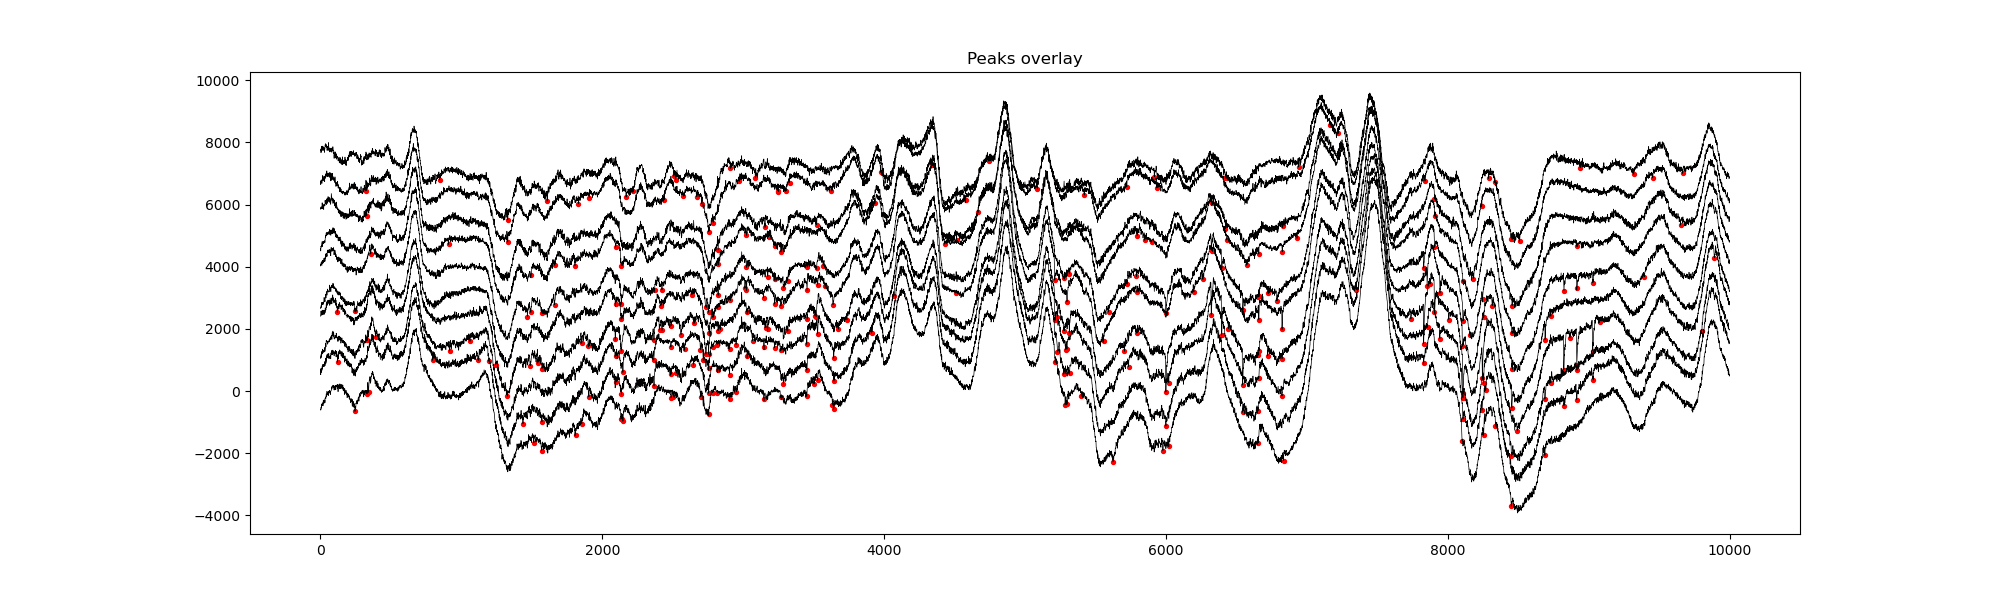

In [22]:
fs = 20000
p = peaks3_3
k2 = False
trace_data = si.preprocessing.common_reference(recording = KS_P1, reference = 'global', operator='median')    # median may be better as its not sensitive to big spikes or bad channels / more robust 


start_s = 10
duration_s = 0.5

start = int(start_s * fs)
end = int((start_s + duration_s) * fs)

traces = trace_data.get_traces(start_frame=start, end_frame=end)

# shift peaks into window
mask = (p["sample_index"] >= start) & (p["sample_index"] < end)
peaks_win = p[mask]
if k2:
    color = 'red' 
else:
    color = 'green' 


num_ch = 10
offset = 800 # vertical spacing

plt.figure(figsize=(20, 6))

for ch in range(num_ch):
    
    plt.plot(traces[:, ch] + ch * offset, color='black', linewidth=0.5)

    p = peaks_win[peaks_win["channel_index"] == ch]
    times = p["sample_index"] - start

    plt.scatter(times, traces[times, ch] + ch * offset, color='red', s=8)

plt.title("Peaks overlay")
plt.show()




In [23]:
def match_peaks_tol(peaks1, peaks2, tol=2):
    t1, c1 = peaks1["sample_index"], peaks1["channel_index"]
    t2, c2 = peaks2["sample_index"], peaks2["channel_index"]

    order2 = np.lexsort((t2, c2))
    t2s, c2s = t2[order2], c2[order2]

    matched1 = np.zeros(len(peaks1), dtype=bool)

    for ch in np.unique(c1):
        idx1 = np.where(c1 == ch)[0]

        left = np.searchsorted(c2s, ch, side="left")
        right = np.searchsorted(c2s, ch, side="right")
        if left == right:
            continue

        t2_ch = t2s[left:right]
        t1_ch = t1[idx1]

        pos = np.searchsorted(t2_ch, t1_ch)

        match = np.zeros(len(t1_ch), dtype=bool)

        valid = pos < len(t2_ch)
        match[valid] |= np.abs(t2_ch[pos[valid]] - t1_ch[valid]) <= tol

        valid = pos > 0
        match[valid] |= np.abs(t2_ch[pos[valid]-1] - t1_ch[valid]) <= tol

        matched1[idx1] = match

    return matched1



m3 = match_peaks_tol(peaks3_5, peaks3_3, tol=5)
m4 = match_peaks_tol(peaks3_3, peaks3_5, tol=5)

common = peaks3_5[m3]
u3 = peaks3_5[~m3]
u4 = peaks3_3[~m4]

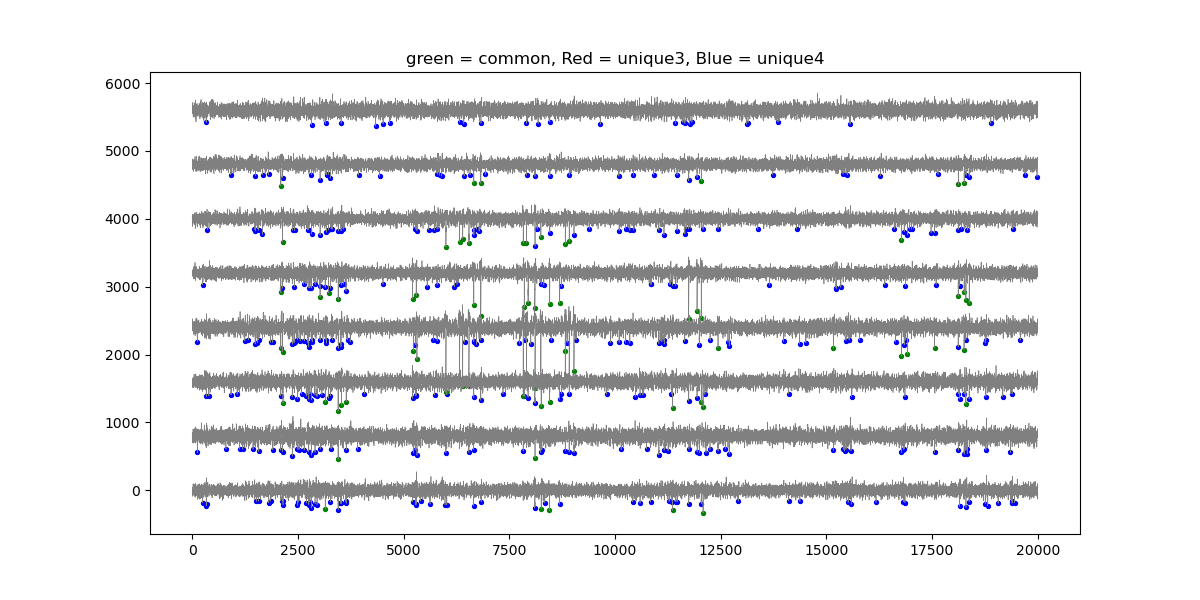

In [24]:
fs = KS_P2.get_sampling_frequency()

start_s = 10
duration_s = 1

start = int(start_s * fs)
end = int((start_s + duration_s) * fs)

traces = KS_P3.get_traces(start_frame=start, end_frame=end)

num_ch = 8
offset = 800

plt.figure(figsize=(12, 6))

for ch in range(num_ch):
    plt.plot(traces[:, ch] + ch*offset, color='gray', linewidth=0.5)

    def plot_group(peaks, color):
        mask = (
            (peaks["channel_index"] == ch) &
            (peaks["sample_index"] >= start) &
            (peaks["sample_index"] < end)
        )
        p = peaks[mask]
        t = p["sample_index"] - start
        plt.scatter(t, traces[t, ch] + ch*offset, color=color, s=8)

    plot_group(common, 'green')
    plot_group(u3, 'red')
    plot_group(u4, 'blue')

plt.title("green = common, Red = unique3, Blue = unique4")
plt.show()



In [ ]:
w_ts = sw.plot_traces(recording, channel_ids=channel_ids[:10])

In [ ]:
def rms_per_channel(rec, duration_s=30):
    fs = rec.get_sampling_frequency()
    traces = rec.get_traces(end_frame=int(fs*duration_s), return_scaled=True)
    return np.sqrt(np.mean(traces**2, axis=0))



# Spike sorting

In [59]:
from spikeinterface.sorters import run_sorter, get_default_sorter_params, get_sorter_params_description

params = get_default_sorter_params('kilosort4')
print("Parameters:\n", params)

descriptions = get_sorter_params_description('kilosort4')
print("Descriptions:\n", descriptions)

print(descriptions['dmin'])


Parameters:
 {'batch_size': 60000, 'nblocks': 1, 'Th_universal': 9, 'Th_learned': 8, 'nt': 61, 'shift': None, 'scale': None, 'batch_downsampling': 1, 'artifact_threshold': inf, 'nskip': 25, 'whitening_range': 32, 'highpass_cutoff': 300, 'binning_depth': 5, 'sig_interp': 20, 'drift_smoothing': [0.5, 0.5, 0.5], 'nt0min': None, 'dmin': None, 'dminx': 32, 'min_template_size': 10, 'template_sizes': 5, 'nearest_chans': 10, 'nearest_templates': 100, 'max_channel_distance': 32, 'max_peels': 100, 'templates_from_data': True, 'n_templates': 6, 'n_pcs': 6, 'Th_single_ch': 6, 'acg_threshold': 0.2, 'ccg_threshold': 0.25, 'cluster_neighbors': 10, 'cluster_downsampling': 20, 'max_cluster_subset': 25000, 'x_centers': None, 'cluster_init_seed': 5, 'duplicate_spike_ms': 0.25, 'position_limit': 100, 'do_CAR': True, 'invert_sign': False, 'save_extra_vars': False, 'save_preprocessed_copy': False, 'torch_device': 'auto', 'bad_channels': None, 'clear_cache': False, 'do_correction': True, 'skip_kilosort_prepr

In [66]:
KS4_params = {
 'batch_size': 120000,
 #'dminx': 10,
 'do_CAR': False,
 'do_correction': False, # False = don't do drift correction
 'max_threads_per_worker': 1,
 'max_channel_distance': 150,
 'n_jobs': 1,
 'nblocks': 0,
 'nearest_chans': 10,
 'nearest_templates': 32,
 'Th_universal': 10,
 'Th_learned': 9,
 'nt': 41,
 'pool_engine': 'process',
 'progress_bar': True,
 'scale': uV_per_count, # set to make sure the traces are +- 100 as desired by kilosort  
 'skip_kilosort_preprocessing': True,
 'torch_device': 'cuda'}

sorting_KS4 = run_sorter(sorter_name='kilosort4', recording=KS_P3, folder='SI_SortingResults/KS4_May_18_2026', docker_image="ks4-blackwell-cu128", verbose=True,**KS4_params, remove_existing_folder=True)                         

installation_mode='auto' switching to installation_mode: 'github'
Starting container
Installing spikeinterface with github in container
Running kilosort4 sorter inside ks4-blackwell-cu128
Stopping container


SpikeSortingError: Spike sorting in docker failed with the following error:
write_binary_recording (no parallelization):   0%|          | 0/3795 [00:00<?, ?it/s]write_binary_recording (no parallelization):   0%|          | 3/3795 [00:00<03:29, 18.12it/s]write_binary_recording (no parallelization):   0%|          | 5/3795 [00:00<03:20, 18.89it/s]write_binary_recording (no parallelization):   0%|          | 8/3795 [00:00<03:12, 19.68it/s]write_binary_recording (no parallelization):   0%|          | 11/3795 [00:00<03:06, 20.28it/s]write_binary_recording (no parallelization):   0%|          | 14/3795 [00:00<03:05, 20.33it/s]write_binary_recording (no parallelization):   0%|          | 17/3795 [00:00<03:03, 20.62it/s]write_binary_recording (no parallelization):   1%|          | 20/3795 [00:00<03:04, 20.49it/s]write_binary_recording (no parallelization):   1%|          | 23/3795 [00:01<03:03, 20.59it/s]write_binary_recording (no parallelization):   1%|          | 26/3795 [00:01<03:

The following data is created as an output from the run_sorter function w/ Kilsort4:



***
***

Current questions: 
- distances between contact sites for our flexible electrodes are not constant
- probes are not inserted vertically so they have a z component as well, does this make a difference
- the xc are all identical as we assume contact sites to be about stacked on the vertical axis. is this a valid assumption 

***

***

**consider using the read_binary_folder function to concatinate multiple sessions together

*** 
## Analyzing Sorting Results

In [ ]:
from spikeinterface.extractors import read_kilosort_as_analyzer

job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer = si.create_sorting_analyzer(sorting_KS4, clean_recording)

#output_path = 'SI_SortingResults/KS4_April_22_2026/sorter_output'
#sorting_analyzer = read_kilosort_as_analyzer(output_path, gain_to_uV=0.195, offset_to_uV=0.0)
#sorting_analyzer.set_temporary_recording(clean_recording)

sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)

# ----------------------------------------------------------------------------------------------------------------------------



NameError: name 'sorting_KS4' is not defined

Open the SpikeInterface GUI to analyze data

In [67]:
# load either with python or with spikeinterface 

sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")

NameError: name 'sorting_analyzer' is not defined

In [ ]:
sw.plot_unit_locations(sorting_analyzer, figsize=(4, 8))


In [ ]:
unit_ids = sorting_analyzer.unit_ids[:4]
sw.plot_unit_waveforms_density_map(sorting_analyzer, unit_ids=unit_ids, figsize=(14, 8))

In [ ]:
unit_ids = sorting_analyzer.unit_ids
sw.plot_unit_probe_map(sorting_analyzer, unit_ids=[14], figsize=(20, 8))


plt.show()

In [ ]:
unit_ids = sorting_analyzer.unit_ids
sw.plot_unit_waveforms(sorting_analyzer, unit_ids=[14], figsize=(16, 4))


In [ ]:
ext_templates = sorting_analyzer.get_extension("templates")

av_templates = ext_templates.get_data(operator="average")

for unit_index, unit_id in enumerate(sorting_analyzer.unit_ids[10:20]):
    fig, ax = plt.subplots()
    template = av_templates[unit_index]
    ax.plot(template)
    ax.set_title(f"{unit_id}")

***

## Comparing Kilosort 4 and JRClust

SpikeInterface accepts the following output data formats 
- `JRCSortingExtractor`
- `KiloSortSortingExtractor`

Available keys: ['#refs#', '#subsystem#', 'annotatedOnly', 'centerSites', 'clusterCenters', 'clusterCentroids', 'clusterNotes', 'clusterSites', 'curatedOn', 'detectTime', 'detectedOn', 'editPos', 'featuresShape', 'filtShape', 'history', 'initialClustering', 'meanSiteThresh', 'meanWfGlobal', 'meanWfGlobalRaw', 'meanWfLocal', 'meanWfLocalRaw', 'meanWfRawHigh', 'meanWfRawLow', 'nSitesOverThresh', 'nSpikes', 'ordRho', 'rawShape', 'rhoCutGlobal', 'rhoCutSite', 'rhoCuts', 'siteRMS', 'siteThresh', 'sortTime', 'sortedOn', 'spikeAmps', 'spikeClusters', 'spikeDelta', 'spikeNeigh', 'spikePositions', 'spikeRho', 'spikeSites', 'spikeSites2', 'spikeSites3', 'spikeTimes', 'spikesByCluster', 'spikesBySite', 'spikesBySite2', 'spikesBySite3', 'unitCount', 'unitISIRatio', 'unitIsoDist', 'unitLRatio', 'unitPeakSites', 'unitPeaks', 'unitPeaksRaw', 'unitSNR', 'unitVpp', 'unitVppRaw', 'waveformSim']


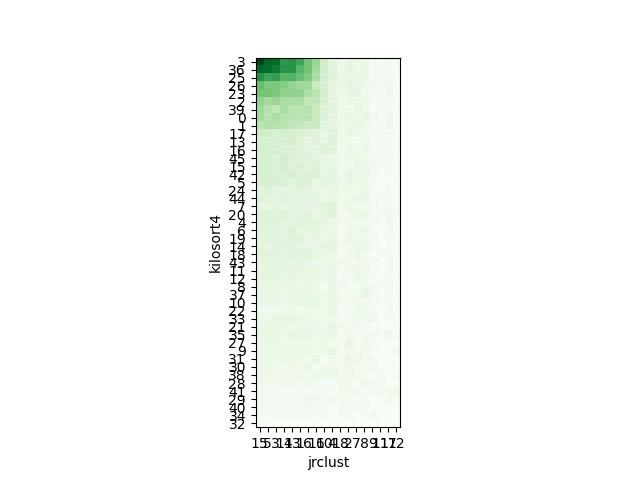

In [ ]:
import spikeinterface.extractors as se
from pathlib import Path
import numpy as np
import scipy.io as sio
import spikeinterface.comparison as scmp
import spikeinterface.widgets as sw
import h5py
import matplotlib.pyplot as plt

%matplotlib widget

JRC_path = r"E:\Data\mPG_VV\3171_day12_260420_124757\pruned"
KS4_path = r"C:\Users\social\Desktop\temp_Brune\SpikeExplore\kilosort_output\victor\april_28_2026_b"

def read_jrclust_sorting_hdf5(jrclust_folder, sampling_frequency):
    jrclust_folder = Path(jrclust_folder)

    res_files = list(jrclust_folder.glob("*_res.mat"))
    if len(res_files) != 1:
        raise ValueError(f"Expected one *_res.mat file, found {len(res_files)}: {res_files}")

    res_file = res_files[0]

    with h5py.File(res_file, "r") as f:
        print("Available keys:", list(f.keys()))

        spike_times = np.array(f["spikeTimes"]).squeeze().astype("int64")
        # TODO unsure about this line below 
        spike_times = spike_times - 1
        spike_labels = np.array(f["spikeClusters"]).squeeze().astype("int64")

    # MATLAB/HDF5 sometimes gives shape (1, n) or (n, 1)
    spike_times = spike_times.ravel()
    spike_labels = spike_labels.ravel()

    # Keep only assigned clusters
    valid = spike_labels > 0

    spike_times = spike_times[valid]
    spike_labels = spike_labels[valid]

    # Sort by spike time
    order = np.argsort(spike_times)
    spike_times = spike_times[order]
    spike_labels = spike_labels[order]

    sorting = se.NumpySorting.from_samples_and_labels(
        samples_list=[spike_times],
        labels_list=[spike_labels],
        sampling_frequency=sampling_frequency,
    )

    return sorting


jr_sorting = read_jrclust_sorting_hdf5(JRC_path, sampling_frequency=20000.0)

ks4_sorting = se.read_kilosort(KS4_path, keep_good_only=False)
cmp = scmp.compare_two_sorters(
    sorting1=ks4_sorting,
    sorting2=jr_sorting,
    sorting1_name="kilosort4",
    sorting2_name="jrclust",
    delta_time=0.4,  # ms), ( SI default is commonly 0.4 ms
)

sw.plot_agreement_matrix(cmp, ordered=True, backend="matplotlib")


